# GI-Stratified Evaluation of scGPT on Norman 2019

Loads saved `per_perturbation_results.csv` from scGPT training notebook,
computes genetic interaction (GI) types directly from the data,
and produces the stratified evaluation table.

**Norman et al. (2019) manifold decomposition:**
$\delta_{ab} = c_1 \delta_a + c_2 \delta_b + \epsilon$
where $\epsilon$ = neomorphic residual, $c_1,c_2$ = dominance weights.

**References:**
- Norman et al., *Science* (2019). DOI: 10.1126/science.aax4438
- Roohani et al. (GEARS), *Nat Biotech* (2024). DOI: 10.1038/s41587-023-02055-5
- Cui et al. (scGPT), *Nat Methods* (2024). DOI: 10.1038/s41592-024-02201-0

In [36]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy import sparse
from sklearn.linear_model import LinearRegression
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## 1. Load saved scGPT results + adata

In [37]:
# Find the saved results directory (timestamped)
save_dirs = sorted(glob.glob("./save/dev_perturb_norman-*"))
assert len(save_dirs) > 0, "No save directory found. Run from the same working dir as your training notebook."
save_dir = Path(save_dirs[-1])  # latest run
print(f"Using save dir: {save_dir}")

# Load per-perturbation results from training notebook (Section 12)
results_csv = save_dir / "per_perturbation_results.csv"
scgpt_results = pd.read_csv(results_csv)
print(f"Loaded {len(scgpt_results)} perturbation results")
scgpt_results.head()

Using save dir: save/dev_perturb_norman-Mar05-13-24
Loaded 114 perturbation results


,perturbation,model,pcc_top20,pcc_all,mse_top20,n_cells
0,AHR+FEV,scGPT_vanilla,0.488625,0.496339,1.692095,264
1,ARID1A+ctrl,scGPT_vanilla,0.675434,0.478009,0.502844,182
2,ARRDC3+ctrl,scGPT_vanilla,0.494994,0.320750,0.065864,405
3,BCL2L11+TGFBR2,scGPT_vanilla,0.751333,0.434210,0.100982,382
4,C3orf72+FOXL2,scGPT_vanilla,0.787781,0.458974,0.352183,49


In [38]:
# Load the same adata used for training
data_path = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"
adata = sc.read_h5ad(data_path)

# Reproduce exact preprocessing from training notebook
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()

print(f"adata: {adata.shape}")
print(f"Conditions: {adata.obs['condition'].nunique()}")

adata: (89357, 5045)
Conditions: 277


In [39]:
adata

AnnData object with n_obs × n_vars = 89357 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'split', 'gears_split'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20', 'log1p'
    layers: 'counts'

## 2. Compute per-condition mean expression profiles

In [40]:
# Control mean
ctrl_mask = adata.obs['condition'] == 'ctrl'
X_ctrl = adata[ctrl_mask].X
if sparse.issparse(X_ctrl):
    X_ctrl = X_ctrl.toarray()
ctrl_mean = X_ctrl.mean(axis=0).flatten()
print(f"Control cells: {ctrl_mask.sum()}")

# Mean expression per condition
conditions = adata.obs['condition'].unique()
cond_means = {}
cond_deltas = {}  # delta from control
cond_ncells = {}

for cond in conditions:
    mask = adata.obs['condition'] == cond
    X = adata[mask].X
    if sparse.issparse(X):
        X = X.toarray()
    cond_means[cond] = X.mean(axis=0).flatten()
    cond_deltas[cond] = cond_means[cond] - ctrl_mean
    cond_ncells[cond] = mask.sum()

print(f"Computed profiles for {len(cond_means)} conditions")

Control cells: 7353
Computed profiles for 277 conditions


## 3. Identify combo vs single perturbations

In [41]:
def parse_condition(cond):
    """Parse condition string into (gene_a, gene_b, is_combo)."""
    if '+' not in cond:
        return cond, None, False
    parts = cond.split('+')
    if len(parts) != 2:
        return cond, None, False
    a, b = parts
    if a == 'ctrl' and b == 'ctrl':
        return None, None, False
    if a == 'ctrl':
        return b, None, False  # single perturbation
    if b == 'ctrl':
        return a, None, False  # single perturbation
    return a, b, True  # combo

# Build lookup: gene_name -> single-perturbation delta
# A single perturbation can appear as "GENE+ctrl" or "ctrl+GENE"
single_deltas = {}
for cond in conditions:
    gene_a, gene_b, is_combo = parse_condition(cond)
    if gene_a is not None and not is_combo:
        single_deltas[gene_a] = cond_deltas[cond]

print(f"Single perturbation profiles: {len(single_deltas)}")

# Identify combo perturbations
combos = []
for cond in conditions:
    gene_a, gene_b, is_combo = parse_condition(cond)
    if is_combo:
        combos.append({'condition': cond, 'gene_a': gene_a, 'gene_b': gene_b})

combos_df = pd.DataFrame(combos)
print(f"Combo perturbations: {len(combos_df)}")

Single perturbation profiles: 103
Combo perturbations: 128


## 4. Compute GI scores + Norman manifold decomposition

For each combo A+B:
- **GI score** (per gene): $\text{GI}_g = \delta_{ab,g} - (\delta_{a,g} + \delta_{b,g})$
- **Manifold decomposition**: $\delta_{ab} = c_1 \delta_a + c_2 \delta_b + \epsilon$
  - $c_1, c_2$: dominance coefficients
  - $\epsilon$: neomorphic residual
  - $R^2$: how well additive model explains the combo

In [42]:
gi_records = []
skipped = []

for _, row in combos_df.iterrows():
    cond = row['condition']
    ga, gb = row['gene_a'], row['gene_b']
    
    # Need single-gene deltas for both genes
    if ga not in single_deltas or gb not in single_deltas:
        skipped.append(cond)
        continue
    
    delta_ab = cond_deltas[cond]
    delta_a = single_deltas[ga]
    delta_b = single_deltas[gb]
    
    # --- GI score ---
    additive_expect = delta_a + delta_b
    gi_vector = delta_ab - additive_expect  # per-gene GI
    
    # Top 20 DE genes of the combo (by absolute delta)
    top20_idx = np.argsort(np.abs(delta_ab))[-20:]
    gi_top20 = gi_vector[top20_idx]
    
    # --- Norman manifold decomposition ---
    X_reg = np.column_stack([delta_a, delta_b])
    reg = LinearRegression(fit_intercept=False).fit(X_reg, delta_ab)
    c1, c2 = reg.coef_
    epsilon = delta_ab - reg.predict(X_reg)
    ss_res = np.sum(epsilon ** 2)
    ss_tot = np.sum((delta_ab - delta_ab.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-10)
    
    # --- Additive baseline prediction quality ---
    # MSE and PCC of additive_expect vs actual delta_ab on top-20
    mse_additive_top20 = np.mean((additive_expect[top20_idx] - delta_ab[top20_idx]) ** 2)
    r_additive_top20, _ = pearsonr(additive_expect[top20_idx], delta_ab[top20_idx])
    
    gi_records.append({
        'condition': cond,
        'gene_a': ga,
        'gene_b': gb,
        # GI metrics
        'gi_magnitude_top20': np.linalg.norm(gi_top20),
        'gi_mean_signed_top20': np.mean(gi_top20),
        'gi_magnitude_all': np.linalg.norm(gi_vector),
        # Manifold decomposition
        'c1': c1,
        'c2': c2,
        'r2_additive': r2,
        'epsilon_norm': np.linalg.norm(epsilon),
        'epsilon_norm_top20': np.linalg.norm(epsilon[top20_idx]),
        # Additive baseline
        'mse_additive_top20': mse_additive_top20,
        'pcc_additive_top20': r_additive_top20 if not np.isnan(r_additive_top20) else 0.0,
    })

gi_df = pd.DataFrame(gi_records)
print(f"Computed GI for {len(gi_df)} combos ({len(skipped)} skipped — missing single-gene data)")
if skipped:
    print(f"  Skipped: {skipped[:5]}{'...' if len(skipped) > 5 else ''}")

Computed GI for 128 combos (0 skipped — missing single-gene data)


## 5. Classify GI types from data

Using data-driven thresholds (since we're computing from expression, not using Norman's Table S3 directly):

| Type | Criterion |
|------|----------|
| **Additive** | Low GI magnitude, high $R^2$ |
| **Synergistic** | Large positive GI (combo > sum of parts) |
| **Suppressive** | Large negative GI (combo < sum of parts) |
| **Neomorphic** | Low $R^2$, large $\|\epsilon\|$ (qualitatively new pattern) |

In [43]:
# Thresholds: use quartiles of the GI magnitude distribution
gi_mag_q25 = gi_df['gi_magnitude_top20'].quantile(0.25)
gi_mag_q75 = gi_df['gi_magnitude_top20'].quantile(0.75)
r2_threshold = 0.5

print(f"GI magnitude quartiles: Q25={gi_mag_q25:.3f}, Q75={gi_mag_q75:.3f}")
print(f"R² additive range: {gi_df['r2_additive'].min():.3f} — {gi_df['r2_additive'].max():.3f}")

def classify_gi(row):
    # Neomorphic: additive model fits poorly AND large residual
    if row['r2_additive'] < r2_threshold and row['epsilon_norm_top20'] > gi_mag_q75:
        return 'neomorphic'
    # Additive: small GI magnitude
    if row['gi_magnitude_top20'] <= gi_mag_q25:
        return 'additive'
    # Synergistic vs suppressive by sign
    if row['gi_mean_signed_top20'] > 0:
        return 'synergistic'
    return 'suppressive'

gi_df['gi_type'] = gi_df.apply(classify_gi, axis=1)
print(f"\nGI type distribution:")
print(gi_df['gi_type'].value_counts().to_string())

GI magnitude quartiles: Q25=0.971, Q75=1.944
R² additive range: 0.189 — 0.967

GI type distribution:
gi_type
suppressive    49
synergistic    47
additive       32


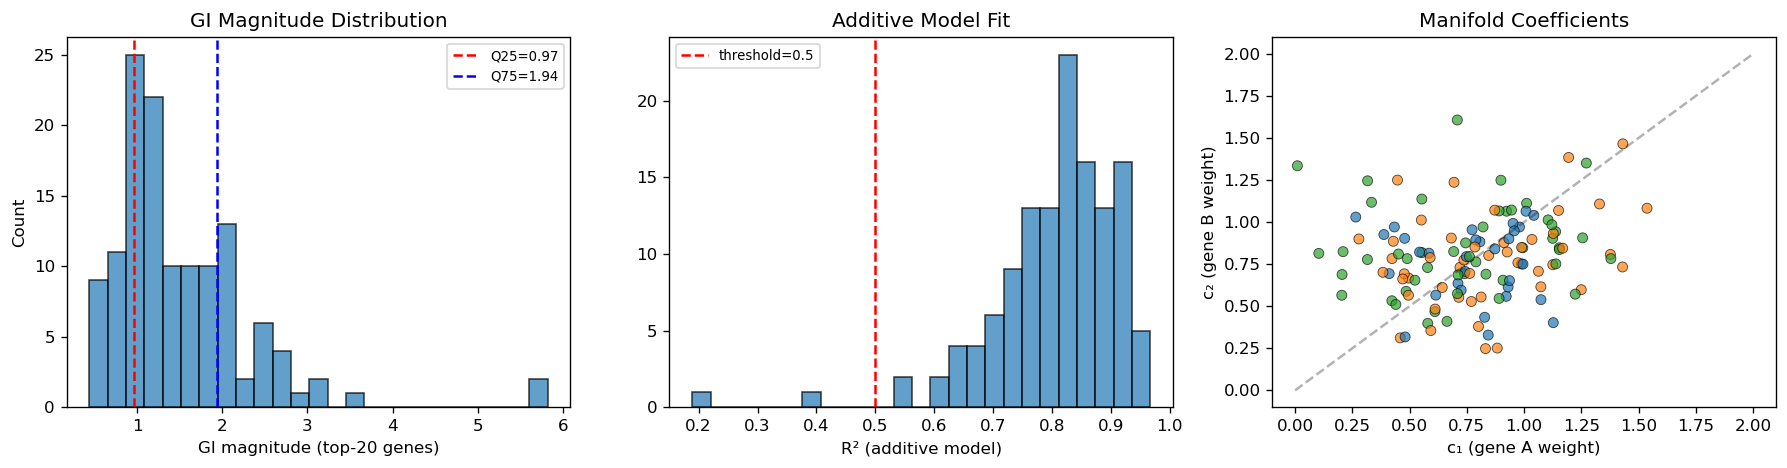

In [44]:
# Diagnostic: GI magnitude distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(gi_df['gi_magnitude_top20'], bins=25, edgecolor='k', alpha=0.7)
axes[0].axvline(gi_mag_q25, color='r', ls='--', label=f'Q25={gi_mag_q25:.2f}')
axes[0].axvline(gi_mag_q75, color='b', ls='--', label=f'Q75={gi_mag_q75:.2f}')
axes[0].set_xlabel('GI magnitude (top-20 genes)')
axes[0].set_ylabel('Count')
axes[0].set_title('GI Magnitude Distribution')
axes[0].legend(fontsize=8)

axes[1].hist(gi_df['r2_additive'], bins=25, edgecolor='k', alpha=0.7)
axes[1].axvline(r2_threshold, color='r', ls='--', label=f'threshold={r2_threshold}')
axes[1].set_xlabel('R² (additive model)')
axes[1].set_title('Additive Model Fit')
axes[1].legend(fontsize=8)

axes[2].scatter(gi_df['c1'], gi_df['c2'], c=gi_df['gi_type'].map(
    {'additive': 'C0', 'synergistic': 'C1', 'suppressive': 'C2', 'neomorphic': 'C3'}),
    alpha=0.7, edgecolors='k', linewidths=0.5)
axes[2].plot([0, 2], [0, 2], 'k--', alpha=0.3)
axes[2].set_xlabel('c₁ (gene A weight)')
axes[2].set_ylabel('c₂ (gene B weight)')
axes[2].set_title('Manifold Coefficients')

plt.tight_layout()
plt.savefig(save_dir / 'gi_classification_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Merge scGPT results with GI annotations

In [45]:
# scgpt_results has column 'perturbation'; gi_df has 'condition'
# Also need to handle: scgpt_results may have singles (GENE+ctrl) that aren't in gi_df

# Tag singles vs combos in scgpt_results
def is_combo(pert):
    if '+' not in pert:
        return False
    parts = pert.split('+')
    return len(parts) == 2 and parts[0] != 'ctrl' and parts[1] != 'ctrl'

scgpt_results['is_combo'] = scgpt_results['perturbation'].apply(is_combo)
print(f"scGPT results: {scgpt_results['is_combo'].sum()} combos, "
      f"{(~scgpt_results['is_combo']).sum()} singles")

# Merge combos with GI data
# Try both orderings for matching
gi_lookup = {}
for _, row in gi_df.iterrows():
    gi_lookup[row['condition']] = row
    # Also store reversed key
    gi_lookup[f"{row['gene_b']}+{row['gene_a']}"] = row

merged_rows = []
for _, r in scgpt_results.iterrows():
    pert = r['perturbation']
    base = r.to_dict()
    if pert in gi_lookup:
        gi_row = gi_lookup[pert]
        base['gi_type'] = gi_row['gi_type']
        base['gi_magnitude_top20'] = gi_row['gi_magnitude_top20']
        base['r2_additive'] = gi_row['r2_additive']
        base['epsilon_norm_top20'] = gi_row['epsilon_norm_top20']
        base['c1'] = gi_row['c1']
        base['c2'] = gi_row['c2']
        base['mse_additive_top20'] = gi_row['mse_additive_top20']
        base['pcc_additive_top20'] = gi_row['pcc_additive_top20']
    else:
        base['gi_type'] = 'single' if not r['is_combo'] else 'no_single_data'
        for col in ['gi_magnitude_top20', 'r2_additive', 'epsilon_norm_top20',
                     'c1', 'c2', 'mse_additive_top20', 'pcc_additive_top20']:
            base[col] = np.nan
    merged_rows.append(base)

eval_df = pd.DataFrame(merged_rows)
print(f"\nMerged: {len(eval_df)} total")
print(eval_df['gi_type'].value_counts().to_string())

scGPT results: 77 combos, 37 singles

Merged: 114 total
gi_type
single         37
suppressive    30
synergistic    28
additive       19


## 7. ⭐ Stratified Results: scGPT vs Additive Baseline by GI Type

In [46]:
# Filter to combos with GI annotation
combo_eval = eval_df[eval_df['gi_type'].isin(['additive', 'synergistic', 'suppressive', 'neomorphic'])].copy()
print(f"Combos with GI annotation: {len(combo_eval)}")

print("\n" + "=" * 80)
print("STRATIFIED RESULTS: scGPT (fine-tuned) vs ADDITIVE BASELINE")
print("=" * 80)
print(f"{'GI Type':<15} {'n':>3}  {'scGPT PCC':>12} {'Additive PCC':>14} "
      f"{'scGPT MSE':>12} {'Additive MSE':>14}")
print("-" * 80)

gi_order = ['additive', 'synergistic', 'suppressive', 'neomorphic']
summary_rows = []

for gi_type in gi_order:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    if len(sub) == 0:
        continue
    row = {
        'gi_type': gi_type,
        'n': len(sub),
        'scgpt_pcc_mean': sub['pcc_top20'].mean(),
        'scgpt_pcc_std': sub['pcc_top20'].std(),
        'additive_pcc_mean': sub['pcc_additive_top20'].mean(),
        'additive_pcc_std': sub['pcc_additive_top20'].std(),
        'scgpt_mse_mean': sub['mse_top20'].mean(),
        'scgpt_mse_std': sub['mse_top20'].std(),
        'additive_mse_mean': sub['mse_additive_top20'].mean(),
        'additive_mse_std': sub['mse_additive_top20'].std(),
    }
    summary_rows.append(row)
    print(f"{gi_type:<15} {row['n']:>3}  "
          f"{row['scgpt_pcc_mean']:>5.3f}±{row['scgpt_pcc_std']:.3f}  "
          f"{row['additive_pcc_mean']:>6.3f}±{row['additive_pcc_std']:.3f}  "
          f"{row['scgpt_mse_mean']:>5.3f}±{row['scgpt_mse_std']:.3f}  "
          f"{row['additive_mse_mean']:>6.3f}±{row['additive_mse_std']:.3f}")

# Overall combos
print("-" * 80)
print(f"{'ALL COMBOS':<15} {len(combo_eval):>3}  "
      f"{combo_eval['pcc_top20'].mean():>5.3f}±{combo_eval['pcc_top20'].std():.3f}  "
      f"{combo_eval['pcc_additive_top20'].mean():>6.3f}±{combo_eval['pcc_additive_top20'].std():.3f}  "
      f"{combo_eval['mse_top20'].mean():>5.3f}±{combo_eval['mse_top20'].std():.3f}  "
      f"{combo_eval['mse_additive_top20'].mean():>6.3f}±{combo_eval['mse_additive_top20'].std():.3f}")

# Also report singles
singles = eval_df[eval_df['gi_type'] == 'single']
if len(singles) > 0:
    print(f"{'SINGLES':<15} {len(singles):>3}  "
          f"{singles['pcc_top20'].mean():>5.3f}±{singles['pcc_top20'].std():.3f}  "
          f"{'N/A':>14}  "
          f"{singles['mse_top20'].mean():>5.3f}±{singles['mse_top20'].std():.3f}  "
          f"{'N/A':>14}")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(save_dir / 'gi_stratified_summary.csv', index=False)

Combos with GI annotation: 77

STRATIFIED RESULTS: scGPT (fine-tuned) vs ADDITIVE BASELINE
GI Type           n     scGPT PCC   Additive PCC    scGPT MSE   Additive MSE
--------------------------------------------------------------------------------
additive         19  0.574±0.278   0.976±0.011  0.335±0.230   0.029±0.011
synergistic      28  0.676±0.118   0.962±0.025  0.829±0.607   0.136±0.085
suppressive      30  0.559±0.226   0.959±0.028  0.966±0.706   0.213±0.284
--------------------------------------------------------------------------------
ALL COMBOS       77  0.605±0.214   0.964±0.024  0.760±0.630   0.139±0.196
SINGLES          37  0.525±0.370             N/A  0.409±0.419             N/A


## 8. Seen-level stratification (GEARS convention)

In [47]:
# Determine which single genes appear in training split
train_mask = adata.obs['gears_split'] == 'train'
train_conditions = set(adata.obs.loc[train_mask, 'condition'].unique())

train_singles = set()
for cond in train_conditions:
    ga, gb, is_c = parse_condition(cond)
    if ga and not is_c:
        train_singles.add(ga)
    if is_c:
        train_singles.add(ga)
        train_singles.add(gb)

print(f"Genes seen in training: {len(train_singles)}")

def get_seen_level(pert):
    ga, gb, is_c = parse_condition(pert)
    if not is_c:
        return 'single'
    return f"seen{int(ga in train_singles) + int(gb in train_singles)}"

eval_df['seen_level'] = eval_df['perturbation'].apply(get_seen_level)

print("\n" + "=" * 60)
print("RESULTS BY SEEN LEVEL")
print("=" * 60)
for level in ['seen0', 'seen1', 'seen2', 'single']:
    sub = eval_df[eval_df['seen_level'] == level]
    if len(sub) == 0:
        continue
    print(f"  {level:<8} | n={len(sub):3d} | "
          f"PCC(top20) = {sub['pcc_top20'].mean():.3f} ± {sub['pcc_top20'].std():.3f} "
          f"(median {sub['pcc_top20'].median():.3f})")

Genes seen in training: 69

RESULTS BY SEEN LEVEL
  seen0    | n= 10 | PCC(top20) = 0.494 ± 0.260 (median 0.506)
  seen1    | n= 52 | PCC(top20) = 0.622 ± 0.216 (median 0.667)
  seen2    | n= 15 | PCC(top20) = 0.621 ± 0.158 (median 0.664)
  single   | n= 37 | PCC(top20) = 0.525 ± 0.370 (median 0.660)


## 9. Visualizations

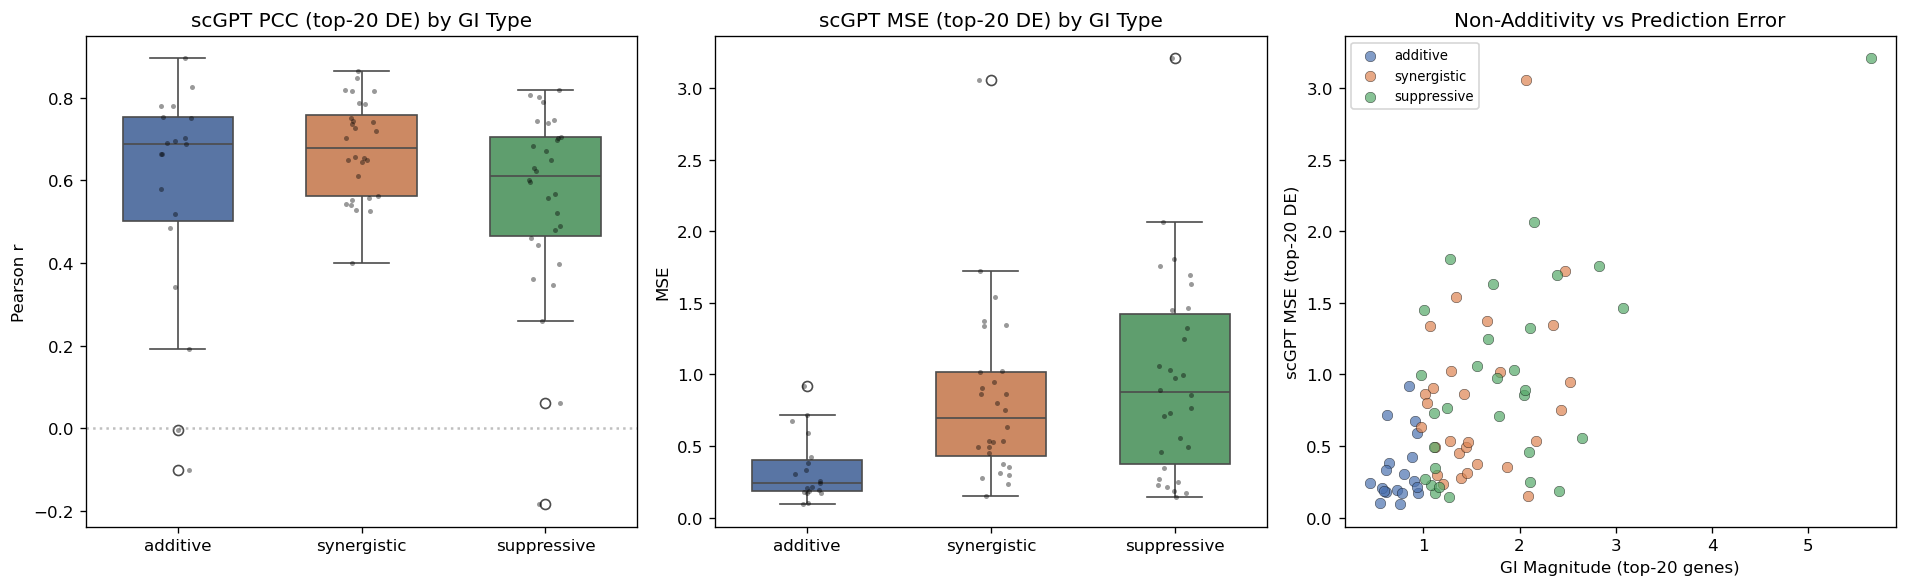

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gi_order_plot = [t for t in gi_order if t in combo_eval['gi_type'].values]
palette = {'additive': '#4C72B0', 'synergistic': '#DD8452',
           'suppressive': '#55A868', 'neomorphic': '#C44E52'}

# 9a. PCC by GI type
sns.boxplot(data=combo_eval, x='gi_type', y='pcc_top20', order=gi_order_plot,
            palette=palette, ax=axes[0], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='pcc_top20', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[0])
axes[0].set_title('scGPT PCC (top-20 DE) by GI Type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Pearson r')
axes[0].axhline(0, color='gray', ls=':', alpha=0.5)

# 9b. MSE by GI type
sns.boxplot(data=combo_eval, x='gi_type', y='mse_top20', order=gi_order_plot,
            palette=palette, ax=axes[1], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='mse_top20', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[1])
axes[1].set_title('scGPT MSE (top-20 DE) by GI Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('MSE')

# 9c. GI magnitude vs prediction error
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[2].scatter(sub['gi_magnitude_top20'], sub['mse_top20'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
axes[2].set_xlabel('GI Magnitude (top-20 genes)')
axes[2].set_ylabel('scGPT MSE (top-20 DE)')
axes[2].set_title('Non-Additivity vs Prediction Error')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(save_dir / 'gi_stratified_eval.png', dpi=150, bbox_inches='tight')
plt.show()

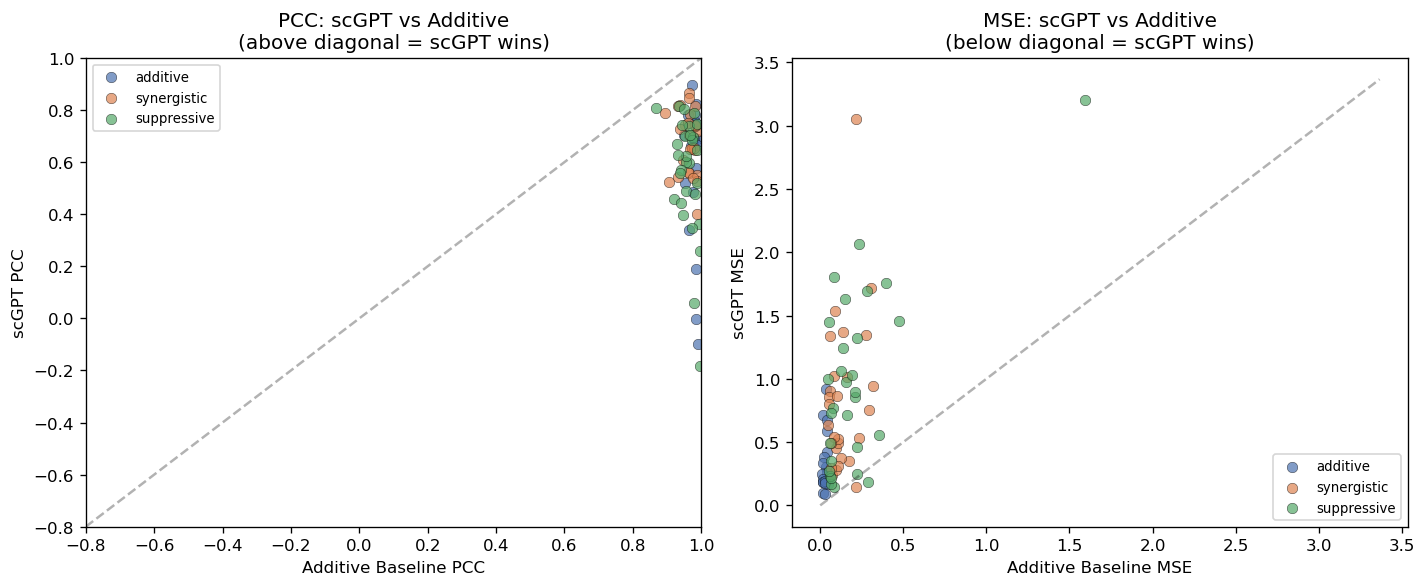


scGPT beats additive baseline (PCC): 0/77 perturbations (0.0%)
scGPT beats additive baseline (MSE): 2/77 perturbations (2.6%)


In [49]:
# scGPT vs Additive baseline scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCC comparison
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[0].scatter(sub['pcc_additive_top20'], sub['pcc_top20'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
lim = [-0.8, 1.0]
axes[0].plot(lim, lim, 'k--', alpha=0.3)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Additive Baseline PCC')
axes[0].set_ylabel('scGPT PCC')
axes[0].set_title('PCC: scGPT vs Additive\n(above diagonal = scGPT wins)')
axes[0].legend(fontsize=8)

# MSE comparison
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[1].scatter(sub['mse_additive_top20'], sub['mse_top20'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
lim_mse = [0, max(combo_eval['mse_top20'].max(), combo_eval['mse_additive_top20'].max()) * 1.05]
axes[1].plot(lim_mse, lim_mse, 'k--', alpha=0.3)
axes[1].set_xlabel('Additive Baseline MSE')
axes[1].set_ylabel('scGPT MSE')
axes[1].set_title('MSE: scGPT vs Additive\n(below diagonal = scGPT wins)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(save_dir / 'scgpt_vs_additive.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stat
scgpt_wins_pcc = (combo_eval['pcc_top20'] > combo_eval['pcc_additive_top20']).sum()
print(f"\nscGPT beats additive baseline (PCC): {scgpt_wins_pcc}/{len(combo_eval)} perturbations "
      f"({100*scgpt_wins_pcc/len(combo_eval):.1f}%)")
scgpt_wins_mse = (combo_eval['mse_top20'] < combo_eval['mse_additive_top20']).sum()
print(f"scGPT beats additive baseline (MSE): {scgpt_wins_mse}/{len(combo_eval)} perturbations "
      f"({100*scgpt_wins_mse/len(combo_eval):.1f}%)")

## 10. Cross-tabulation: Seen Level × GI Type

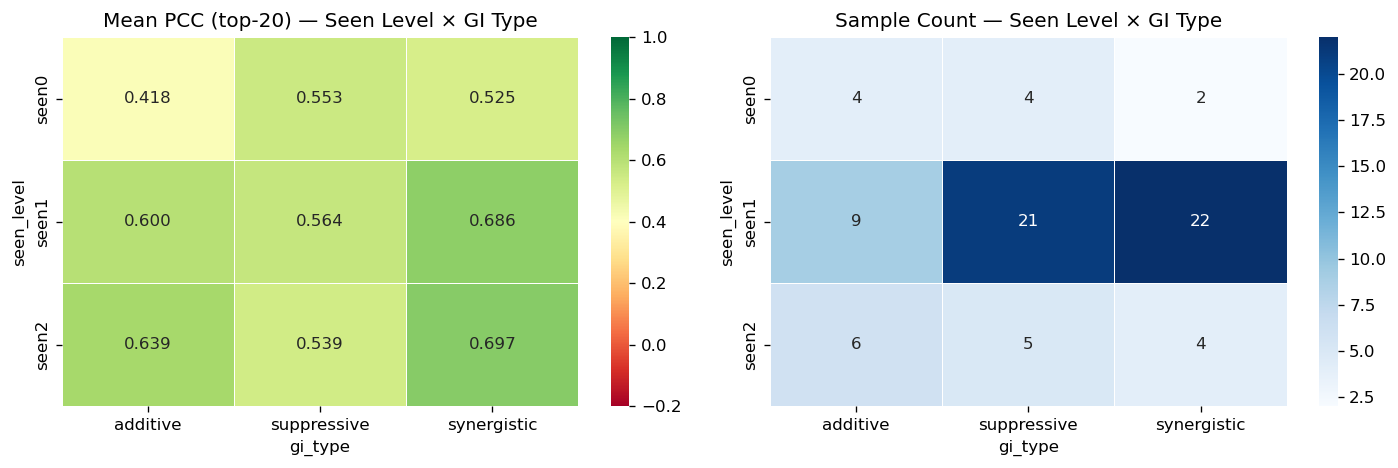

In [50]:
# cross = combo_eval.copy()
cross = eval_df[eval_df['gi_type'].isin(['additive', 'synergistic', 'suppressive', 'neomorphic'])].copy()

cross_pcc = cross.pivot_table(values='pcc_top20', index='seen_level',
                              columns='gi_type', aggfunc='mean')
cross_n = cross.pivot_table(values='perturbation', index='seen_level',
                            columns='gi_type', aggfunc='count')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cross_pcc, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
            vmin=-0.2, vmax=1.0, linewidths=0.5)
axes[0].set_title('Mean PCC (top-20) — Seen Level × GI Type')

sns.heatmap(cross_n.fillna(0).astype(int), annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Sample Count — Seen Level × GI Type')

plt.tight_layout()
plt.savefig(save_dir / 'cross_tab_seen_gi.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Manifold decomposition: which combos have strongest neomorphic effects?

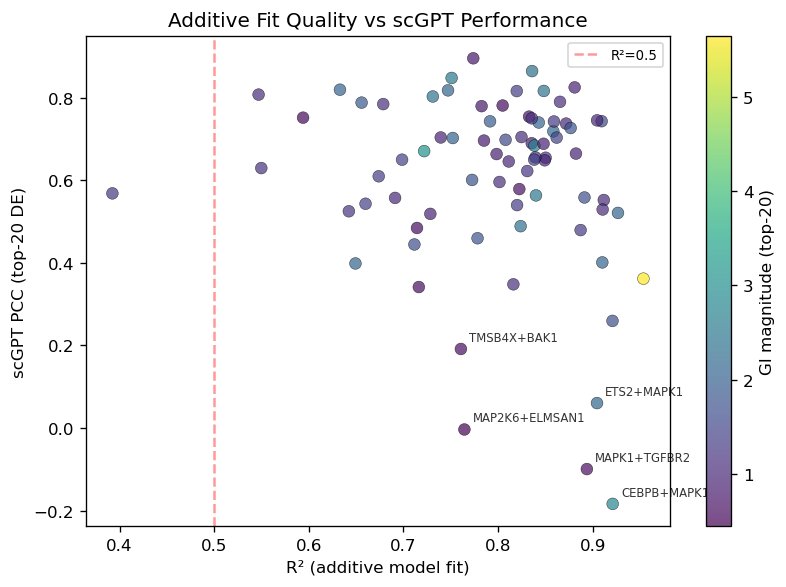


Top 10 most neomorphic perturbations (lowest additive R²):
     condition  r2_additive  epsilon_norm_top20       c1       c2
  BCL2L11+BAK1     0.189271            1.041351 0.480582 0.317357
  KIF18B+KIF2C     0.392377            1.125820 0.663375 0.410015
     PLK4+STIL     0.546913            1.258674 0.553462 1.136945
   PTPN12+OSR2     0.549757            1.268152 0.422666 0.532312
BCL2L11+TGFBR2     0.593935            0.844902 0.747833 0.794752
   CBL+UBASH3A     0.609951            1.838047 1.223366 0.571743
   DUSP9+MAPK1     0.632913            1.618560 0.459239 0.311830
   FOSB+PTPN12     0.642310            1.344828 0.383709 0.701543
   MAP2K6+SPI1     0.649290            1.570189 0.579340 0.398230
 C3orf72+FOXL2     0.655794            1.412156 0.882948 0.251091


In [51]:
# Merge epsilon info with scGPT performance
combo_full = combo_eval.dropna(subset=['r2_additive']).copy()

fig, ax = plt.subplots(figsize=(7, 5))
sc_plt = ax.scatter(combo_full['r2_additive'], combo_full['pcc_top20'],
                    c=combo_full['gi_magnitude_top20'], cmap='viridis',
                    alpha=0.7, edgecolors='k', linewidths=0.3, s=50)
plt.colorbar(sc_plt, label='GI magnitude (top-20)')
ax.set_xlabel('R² (additive model fit)')
ax.set_ylabel('scGPT PCC (top-20 DE)')
ax.set_title('Additive Fit Quality vs scGPT Performance')
ax.axvline(r2_threshold, color='r', ls='--', alpha=0.4, label=f'R²={r2_threshold}')
ax.legend(fontsize=8)

# Label the worst-predicted, most-neomorphic perturbations
worst = combo_full.nsmallest(5, 'pcc_top20')
for _, row in worst.iterrows():
    ax.annotate(row['perturbation'], (row['r2_additive'], row['pcc_top20']),
               fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(save_dir / 'manifold_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top neomorphic perturbations (low R², high epsilon)
print("\nTop 10 most neomorphic perturbations (lowest additive R²):")
top_neo = gi_df.nsmallest(10, 'r2_additive')[['condition', 'r2_additive', 'epsilon_norm_top20', 'c1', 'c2']]
print(top_neo.to_string(index=False))

## 12. Export all results

In [52]:
# Full per-perturbation results with GI annotations
eval_df.to_csv(save_dir / 'eval_with_gi_annotations.csv', index=False)

# GI annotations (reusable for GEARS, CPA, etc.)
gi_df.to_csv(save_dir / 'norman_gi_annotations_computed.csv', index=False)

# Summary table
summary_df.to_csv(save_dir / 'gi_stratified_summary.csv', index=False)

print(f"All outputs saved to {save_dir}/")
print(f"  eval_with_gi_annotations.csv        — per-perturbation results + GI")
print(f"  norman_gi_annotations_computed.csv   — GI types (reuse for other models)")
print(f"  gi_stratified_summary.csv            — summary table")
print(f"  gi_stratified_eval.png               — boxplots by GI type")
print(f"  scgpt_vs_additive.png                — scatter comparison")
print(f"  cross_tab_seen_gi.png                — heatmap")
print(f"  manifold_vs_performance.png           — R² vs performance")

All outputs saved to save/dev_perturb_norman-Mar05-13-24/
  eval_with_gi_annotations.csv        — per-perturbation results + GI
  norman_gi_annotations_computed.csv   — GI types (reuse for other models)
  gi_stratified_summary.csv            — summary table
  gi_stratified_eval.png               — boxplots by GI type
  scgpt_vs_additive.png                — scatter comparison
  cross_tab_seen_gi.png                — heatmap
  manifold_vs_performance.png           — R² vs performance


---

## Next steps

1. Run GEARS on same split → load its `per_perturbation_results.csv` → merge with `norman_gi_annotations_computed.csv` → same stratified analysis
2. If scGPT ≈ additive baseline on non-additive combos → direct motivation for multiplicative attention (Track A)
3. The `norman_gi_annotations_computed.csv` is reusable across all baselines